# Introducción SHAP
Tras el proceso de entrenamiento y selección del modelo predictivo, se procede a analizar la interpretabilidad del modelo mediante técnicas SHAP (SHapley Additive exPlanations).

Es importante destacar que el análisis de interpretabilidad se realiza sobre el modelo previamente entrenado y almacenado, evitando cualquier proceso de reentrenamiento en esta fase. Este enfoque garantiza la coherencia metodológica del estudio, permitiendo interpretar exactamente el modelo utilizado en la fase de predicción.

La reutilización del modelo entrenado asegura la reproducibilidad del pipeline y evita inconsistencias derivadas de posibles variaciones en el proceso de entrenamiento.

# Justificación técnica 

La separación entre la fase de entrenamiento (modelado) y la fase de interpretabilidad responde a buenas prácticas en el desarrollo de sistemas de machine learning. En particular, permite desacoplar el coste computacional del entrenamiento del análisis explicativo, facilitando la escalabilidad del sistema.

Asimismo, este enfoque evita la duplicación de procesos y garantiza que los resultados obtenidos mediante SHAP correspondan exactamente al modelo final seleccionado.

### 1. Carga de datos

In [16]:
import sys
import numpy as np
import pandas as pd
import pyarrow
import sklearn
import zmq
import matplotlib
import joblib
import shap

In [3]:
df = pd.read_parquet("../../data/features/m5_features")

In [26]:
df_store = df

In [5]:
# store = "CA_1"

# df_store = df[df["store_id"] == store].copy()

### 2. Split temporal

In [28]:
df_store["date"] = pd.to_datetime(df_store["date"])

train = df_store[df_store["date"] < "2015-01-01"]

validation = df_store[
    (df_store["date"] >= "2015-01-01") &
    (df_store["date"] < "2016-01-01")
]

test = df_store[df_store["date"] >= "2016-01-01"]

### 3. CARGAR FEATURES

In [29]:
features = joblib.load("../../models/features_store_CA_1.pkl")

### 4. Preparar X_test con features cargadas

In [ ]:
X_test = test[features].copy()

### 5. casteo categóricas

In [11]:
categorical_cols = [
    "store_id", "item_id", "dept_id", "cat_id", "state_id",
    "weekday", "event_name_1", "event_type_1",
    "event_name_2", "event_type_2"
]

for col in categorical_cols:
    X_test[col] = X_test[col].astype("category")

### 5. CARGAR MODELO

In [13]:
model = joblib.load("../../models/lgbm_store_CA_1.pkl")

## Interpretabilidad del modelo mediante SHAP

Tras seleccionar LightGBM como modelo principal, se procede a analizar la contribución individual de las variables predictoras mediante el uso de SHAP (SHapley Additive exPlanations).

SHAP permite cuantificar la influencia de cada variable en las predicciones del modelo, proporcionando una interpretación detallada del comportamiento interno del algoritmo.

Este análisis facilita la comprensión del modelo y permite validar la coherencia entre las variables más influyentes y el conocimiento del dominio del problema.

C:\Users\Titanio\anaconda3\envs\tfm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


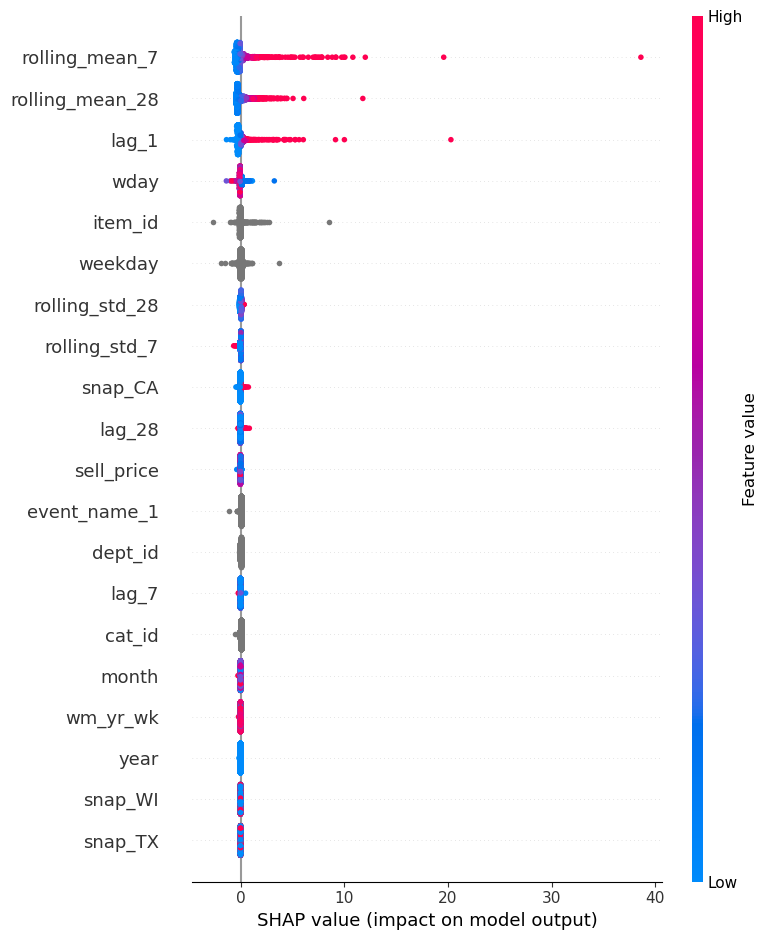

In [14]:
# SHAP Global
import shap

# Crear explainer
explainer = shap.TreeExplainer(model)

# Sample pequeño para velocidad
sample = X_test.sample(2000, random_state=42)

# Calcular SHAP values
shap_values = explainer.shap_values(sample)

# Gráfico global
shap.summary_plot(
    shap_values,
    sample
)

ventas recientes  predicen ventas futuras

## Interpretación global mediante SHAP

El análisis global mediante SHAP revela que las variables temporales derivadas presentan el mayor impacto en las predicciones del modelo.

En particular, la variable `rolling_mean_28` aparece como el factor más influyente, indicando que el comportamiento histórico reciente de la demanda constituye el principal determinante en la predicción futura.

Asimismo, la variable `lag_7` presenta una contribución significativa, reflejando la existencia de patrones semanales en la serie temporal.

Por otro lado, variables relacionadas con el calendario, como `month`, presentan una menor contribución relativa. Este comportamiento es coherente con la presencia de variables temporales derivadas que ya capturan gran parte de la información estacional, reduciendo así la necesidad de variables adicionales menos específicas.

En conjunto, los resultados obtenidos mediante SHAP confirman la relevancia de las variables temporales generadas durante la fase de ingeniería de características.

In [17]:
shap.initjs()

In [18]:
# SHAP LOCAL-- explicar una predicción individual
# Seleccionar un ejemplo individual
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample.iloc[0]
)

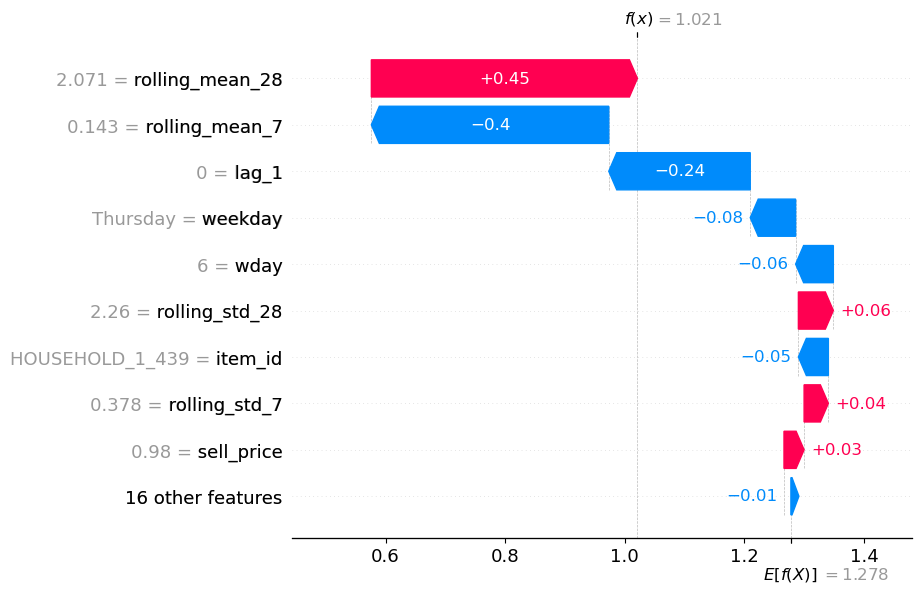

In [19]:
# gráfico local estático

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

## Interpretación local de predicciones mediante SHAP

El análisis local permite identificar las variables que influyen en una predicción individual concreta.

En el ejemplo analizado, se observa que la variable `rolling_mean_28` presenta la mayor contribución positiva, lo que indica que un nivel elevado de ventas recientes incrementa la predicción final del modelo.

Asimismo, variables relacionadas con el calendario, como `weekday`, contribuyen positivamente a la predicción, evidenciando la existencia de patrones semanales en la demanda.

Por otro lado, algunas variables presentan contribuciones negativas, reduciendo ligeramente la predicción estimada. Este comportamiento refleja la interacción compleja entre múltiples factores en la determinación de la demanda.

Este tipo de análisis permite validar la coherencia del modelo y proporciona una interpretación detallada del comportamiento predictivo.

In [24]:
import pandas as pd
df = pd.read_parquet("../../post_analysis/predictions_all.parquet")
print(df.columns)

Index(['store_id', 'item_id', 'dept_id', 'cat_id', 'date', 'prediction'], dtype='object')


In [25]:
print(df.shape)
print(df.head())
print(df["store_id"].nunique())

(58327370, 6)
  store_id      item_id  dept_id cat_id       date  prediction
0     CA_1  FOODS_1_016  FOODS_1  FOODS 2011-01-29    1.617570
1     CA_1  FOODS_2_339  FOODS_2  FOODS 2012-10-28    0.782658
2     CA_1  FOODS_1_016  FOODS_1  FOODS 2011-01-30    2.467605
3     CA_1  FOODS_2_339  FOODS_2  FOODS 2012-10-29    0.546634
4     CA_1  FOODS_1_016  FOODS_1  FOODS 2011-01-31    1.785012
10


La implementación final de reconciliación jerárquica se realiza mediante scripts productivos (build_s_matrix.py, mint.py), ya que el notebook representa únicamente una validación inicial sobre un subconjunto."